<a href="https://colab.research.google.com/github/maitrungtung/IMIS_Machine_Learning/blob/main/Report/IMISToolA2026_Report4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Report 4 (2026/07/27 ver.A)

for Tools for intelligent interaction systems a (0ALE005 / 0AL5707).

---

* Student ID: (E.g. 202099998)...Erase-and-put-yours-here
* Name: (E.g. 筑波 太郎）...Erase-and-put-yours-here
* Colab account: (E.g. tsukuba.taro.xs@alumni.tsukuba.ac.jp)...Erase-and-put-yours-here

---

Report could be written in English or Japanese. / レポートの記述は日本語でも英語でもよい．

---

---
# Report4A: Live capture query with CIFAR-10 or MNIST  

* Show the way to build a classfier of CIFAR10 or MNIST.
* Provide a python program that captures an image from a camera and that shows its recognition result of the image immediately.

Hint: Each shown in tutorials. Find a way to unite them.



**Report 4A — Live camera classification with MNIST**

In this experiment, I build a convolutional neural network (CNN) classifier using the MNIST handwritten-digit dataset. The trained model classifies grayscale images into ten classes from 0 to 9. I then combine the classifier with the camera-capture function of Google Colab so that a handwritten digit captured by the webcam is preprocessed and classified immediately.

The procedure consists of four steps: training an MNIST classifier, evaluating its accuracy, capturing an image from the webcam, and converting the captured image into the same 28 × 28 format used by MNIST before inference.

Device: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.05MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.2MB/s]


Epoch 1/3 | loss = 0.1716
Epoch 2/3 | loss = 0.0502
Epoch 3/3 | loss = 0.0343


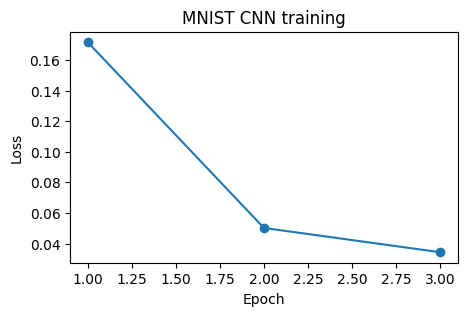

In [1]:
# Report 4A - Build and train an MNIST classifier
import torch, torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.1307,), (0.3081,))])

train_set = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_set = datasets.MNIST("./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)

class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64*7*7,128), nn.ReLU(), nn.Linear(128,10))

    def forward(self, x):
        return self.classifier(self.features(x))

model = MNIST_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs, train_losses = 3, []
for epoch in range(num_epochs):
    model.train(); running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward(); optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs} | loss = {avg_loss:.4f}")

plt.figure(figsize=(5,3))
plt.plot(range(1,num_epochs+1), train_losses, marker="o")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("MNIST CNN training"); plt.show()

In [2]:
# Evaluate on MNIST test set
model.eval(); correct = total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        pred = model(images).argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Test accuracy = {accuracy:.2f}%")

Test accuracy = 98.96%


In [3]:
# Camera capture for Google Colab
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename="mnist_camera.jpg", quality=0.9):
    js = Javascript("""
    async function takePhoto(q) {
      const div=document.createElement('div'), video=document.createElement('video'),
            button=document.createElement('button');
      button.textContent='Capture'; div.appendChild(video); div.appendChild(button);
      document.body.appendChild(div);

      const stream=await navigator.mediaDevices.getUserMedia({video:true});
      video.srcObject=stream; await video.play();
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight,true);
      await new Promise(resolve => button.onclick=resolve);

      const canvas=document.createElement('canvas');
      canvas.width=video.videoWidth; canvas.height=video.videoHeight;
      canvas.getContext('2d').drawImage(video,0,0);
      stream.getVideoTracks()[0].stop(); div.remove();
      return canvas.toDataURL('image/jpeg',q);
    }
    """)
    display(js)
    data = eval_js(f"takePhoto({quality})")
    with open(filename,"wb") as f:
        f.write(b64decode(data.split(",")[1]))
    return filename

print("Camera ready.")

Camera ready.


In [4]:
# Capture -> preprocess -> recognize
def preprocess_digit(filename):
    img = Image.open(filename).convert("L")
    arr = np.array(img)
    h,w = arr.shape
    s = int(min(h,w)*0.75)
    arr = arr[(h-s)//2:(h+s)//2, (w-s)//2:(w+s)//2]

    inv = 255-arr
    mask = inv > 60
    if mask.any():
        ys,xs = np.where(mask)
        inv = inv[ys.min():ys.max()+1, xs.min():xs.max()+1]

    digit = Image.fromarray(inv.astype(np.uint8))
    w,h = digit.size
    scale = 20/max(w,h)
    nw,nh = max(1,int(w*scale)), max(1,int(h*scale))
    digit = digit.resize((nw,nh), Image.Resampling.LANCZOS)

    canvas = Image.new("L",(28,28),0)
    canvas.paste(digit,((28-nw)//2,(28-nh)//2))

    x = transforms.ToTensor()(canvas)
    x = transforms.Normalize((0.1307,),(0.3081,))(x).unsqueeze(0)
    return img, canvas, x

filename = take_photo()
original, processed, x = preprocess_digit(filename)

model.eval()
with torch.no_grad():
    prob = torch.softmax(model(x.to(device)), dim=1)
    pred = prob.argmax(1).item()
    confidence = 100 * prob[0,pred].item()

plt.figure(figsize=(7,3))
plt.subplot(1,2,1); plt.imshow(original,cmap="gray"); plt.title("Camera image"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(processed,cmap="gray"); plt.title(f"Prediction: {pred}"); plt.axis("off")
plt.show()

print(f"Predicted digit = {pred}")
print(f"Confidence = {confidence:.2f}%")

<IPython.core.display.Javascript object>

MessageError: NotAllowedError: Permission denied

(You can put text cells around here)

---
# Report4B: Tutorials of pytorch

There are [many tutorials](https://github.com/kameda-yoshinari/IMISToolExeA2021/blob/master/300_PyTorch.ipynb) provided by the Pytorch official site. Pick up **two tutorials** (you should complete those tutorials) and make a report for the two tutorials on:

* Summary (2-3 lines)
* What you learn
* The most difficult part

Note that you are encouraged to choose the recommended two .


---
# Report4C: AI support to learn python and PyTorch  

Find out the state-of-the-art AI support which is available / helpful on learning how to write python / pytorch codes on google colab.
Then write your own comment on what kind of changes would happen in a couple of years.

* AI service name
* AI service "official web site"
* Major funcitons of provided support
* The service start date and version history (including the URL that holds such info)


(You can put text cells around here)

---
# Report submission

As for Report4, in addition to submit this ipynb, you are also asked to submit 801_miniGPT.ipynb and 802_miniGPT.ipnyb (in total of three files).

You should save this file as a report templete to your local google colaboratory folder and then edit it to fit your report.

The report submission should be made at this cource (0ALE005) at https://manaba.tsukuba.ac.jp .  
Note that 0AL5707 is coupled with 0ALE005 on manaba system, so 0AL5707 students should also submit the report at 0ALE005.  
File extension should be **ipynb**. Other format won't be accepted.  







---
Tools and Practices for Intelligent Interaction Systems A  
Master's and Docotal programs in intelligent and mechanical interaction systems, University of Tsukuba, Japan.  
KAMEDA Yoshinari, SHIBUYA Takeshi  

知能システムツール演習a  
知能機能システム学位プログラム (筑波大学大学院)  
担当：亀田能成，澁谷長史  

2026/07/27. Ver.B. 説明簡略化 / Simplified Explanation  
2026/07/27. Ver.A.  


